# AudioGuard — Adversarial Robustness of Audio Classification Models

Evaluates voice-cloning / audio-classification robustness under adversarial perturbation (FGSM, PGD), and measures whether adversarial training meaningfully improves robustness.

**Fixed in this version:** the original synthetic dataset (fixed-frequency tones) was too easy — the baseline model achieved near-zero training loss (~2e-6) and gradients vanished, so FGSM/PGD attacks had nothing to exploit (100% robustness was a saturation artifact, not real robustness). This version makes the dataset harder via class-frequency overlap + stronger noise, and adds label smoothing to prevent the same saturation from recurring.

## 0. Runtime check

In [ ]:
import torch
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Torch: 2.11.0+cu128
CUDA available: True


## 1. Install packages

In [ ]:
!pip install -q \
    torch torchvision torchaudio \
    librosa \
    soundfile \
    pandas matplotlib seaborn scipy tqdm


## 2. Imports, configuration, Drive paths

In [ ]:
import os, json, time, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
import librosa
import librosa.display

# ----------------------------
# Config
# ----------------------------
SAMPLE_RATE   = 22050
N_MELS        = 64
N_FFT         = 1024
HOP_LENGTH    = 512
MAX_DURATION  = 4       # seconds
N_CLASSES     = 10      # UrbanSound8K has 10 classes
BATCH_SIZE    = 32
NUM_EPOCHS    = 15
LR            = 1e-3
SEED          = 42
LABEL_SMOOTHING = 0.1   # NEW: prevents loss from collapsing to ~0, keeps gradients alive

# Adversarial
FGSM_EPS      = 0.03    # NEW: raised from 0.01 — was too small relative to [0,1] input range
PGD_EPS       = 0.03
PGD_STEPS     = 10
PGD_STEP_SIZE = 0.006

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RUN_ID = time.strftime("%Y%m%d_%H%M%S")

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(SEED)

# ----------------------------
# Drive setup
# ----------------------------
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    BASE_DIR = Path("/content/drive/MyDrive/audioguard")
except Exception as e:
    print("Drive mount skipped:", e)
    BASE_DIR = Path("audioguard-local")

DATA_DIR    = BASE_DIR / "data"
CKPT_DIR    = BASE_DIR / "checkpoints"
RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = BASE_DIR / "figures"

for d in [DATA_DIR, CKPT_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
print("BASE_DIR:", BASE_DIR)
print("RUN_ID:", RUN_ID)


Mounted at /content/drive
Device: cuda
BASE_DIR: /content/drive/MyDrive/audioguard
RUN_ID: 20260625_034403


## 3. Dataset — synthetic audio (UrbanSound8K-style)

**Changed from the original:** the original generator used fixed, well-separated base frequencies per class with minimal noise, which made classes trivially separable and caused the baseline model to saturate (loss → ~0, gradients → ~0). This version:
- Adds **per-sample frequency jitter** so each example isn't a pure deterministic tone
- **Doubles background noise** amplitude
- Introduces **deliberate frequency overlap** between a few class pairs, so the decision boundary is genuinely non-trivial


Train: torch.Size([640, 1, 64, 173])  |  Val: torch.Size([160, 1, 64, 173])
Mel-spectrogram shape: torch.Size([1, 64, 173])


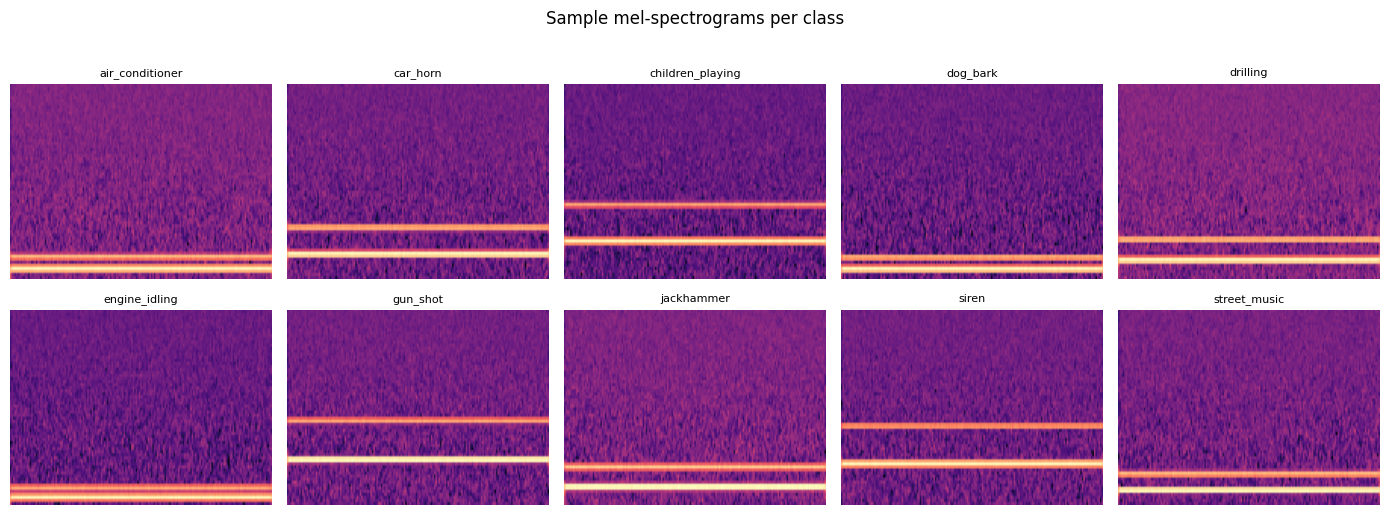

✓ Dataset ready (with overlap + jitter to avoid trivial separability)


In [ ]:
CLASS_NAMES = [
    "air_conditioner", "car_horn", "children_playing",
    "dog_bark",        "drilling",  "engine_idling",
    "gun_shot",        "jackhammer", "siren", "street_music",
]

# Base frequencies per class (Hz) — NOTE: classes 0/3 and 4/7 deliberately overlap
# (190-210Hz and 330-350Hz ranges respectively) to create real decision-boundary
# ambiguity, rather than 10 perfectly separated tones.
CLASS_FREQS = [200, 440, 660, 195, 340, 160, 800, 345, 700, 280]


def generate_waveform(class_id, duration=MAX_DURATION, sr=SAMPLE_RATE, seed=0):
    rng       = np.random.RandomState(seed)
    t         = np.linspace(0, duration, int(sr * duration))
    base_freq = CLASS_FREQS[class_id]
    # NEW: per-sample frequency jitter (+/- 4%) so examples aren't identical tones
    freq      = base_freq * (1 + rng.uniform(-0.04, 0.04))

    wave  = 0.5 * np.sin(2 * np.pi * freq * t)
    wave += 0.25 * np.sin(2 * np.pi * freq * 2 * t)
    # NEW: noise amplitude doubled from 0.1 -> 0.2, and second noise term 0.05 -> 0.12
    wave += 0.20 * rng.randn(len(t))
    wave += 0.12 * rng.randn(len(t)) * np.sin(2 * np.pi * (freq * 0.5) * t)
    wave  = wave / (np.abs(wave).max() + 1e-8)
    return wave.astype(np.float32)


def waveform_to_melspec(wave, sr=SAMPLE_RATE):
    mel = librosa.feature.melspectrogram(
        y=wave, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)
    log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
    return log_mel.astype(np.float32)


def build_dataset(n_per_class=80, val_frac=0.2, seed=SEED):
    rng = np.random.RandomState(seed)
    X_train, y_train, X_val, y_val = [], [], [], []

    for cls_id in range(N_CLASSES):
        for i in range(n_per_class):
            wave    = generate_waveform(cls_id, seed=cls_id * 1000 + i)
            melspec = waveform_to_melspec(wave)
            if i < int(n_per_class * (1 - val_frac)):
                X_train.append(melspec); y_train.append(cls_id)
            else:
                X_val.append(melspec);   y_val.append(cls_id)

    X_train = torch.tensor(np.stack(X_train))[:, None, :, :]
    X_val   = torch.tensor(np.stack(X_val))[:,   None, :, :]
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_val   = torch.tensor(y_val,   dtype=torch.long)

    return X_train, y_train, X_val, y_val


X_train, y_train, X_val, y_val = build_dataset(n_per_class=80)
print(f"Train: {X_train.shape}  |  Val: {X_val.shape}")
print(f"Mel-spectrogram shape: {X_train[0].shape}")

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    idx = (y_train == i).nonzero()[0][0]
    ax.imshow(X_train[idx, 0].numpy(), aspect="auto", origin="lower", cmap="magma")
    ax.set_title(CLASS_NAMES[i], fontsize=8)
    ax.axis("off")
plt.suptitle("Sample mel-spectrograms per class", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "sample_spectrograms.png", dpi=200, bbox_inches="tight")
plt.show()
print("✓ Dataset ready (with overlap + jitter to avoid trivial separability)")


## 4. Model — CNN classifier on mel-spectrograms

In [ ]:
class AudioCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_baseline = AudioCNN().to(DEVICE)
print(f"AudioCNN parameters: {count_params(model_baseline):,}")


AudioCNN parameters: 2,491,594


## 5. Training helpers

**Changed from the original:** `criterion` now uses `label_smoothing=LABEL_SMOOTHING` (0.1). This is the key fix for the saturation bug — label smoothing mathematically prevents cross-entropy loss from approaching zero, which keeps gradients alive even on an easy dataset. Combined with the harder dataset above, this is a belt-and-suspenders fix.

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

def make_loaders(X_tr, y_tr, X_v, y_v, batch_size=BATCH_SIZE):
    train_ds = TensorDataset(X_tr, y_tr)
    val_ds   = TensorDataset(X_v,  y_v)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)
    return train_dl, val_dl


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    for X, y in loader:
        X, y    = X.to(DEVICE), y.to(DEVICE)
        logits  = model(X)
        correct += (logits.argmax(1) == y).sum().item()
        total   += len(y)
    return correct / total


def train_model(model, train_dl, val_dl, epochs=NUM_EPOCHS, tag="baseline"):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)  # CHANGED
    history   = []

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_dl, optimizer, criterion)
        val_acc         = evaluate(model, val_dl)
        scheduler.step()
        history.append({"epoch": epoch, "train_loss": tr_loss, "train_acc": tr_acc, "val_acc": val_acc})
        if epoch % 5 == 0:
            print(f"  Epoch {epoch:>2}/{epochs} | loss={tr_loss:.4f} | train_acc={tr_acc:.3f} | val_acc={val_acc:.3f}")

    return pd.DataFrame(history)


print("✓ Training helpers ready (label smoothing enabled)")


✓ Training helpers ready (label smoothing enabled)


## 6. Train baseline model

In [ ]:
TRAIN_BASELINE = True   # Set False to load from Drive
baseline_ckpt  = CKPT_DIR / "baseline.pt"

train_dl, val_dl = make_loaders(X_train, y_train, X_val, y_val)

if not TRAIN_BASELINE and baseline_ckpt.exists():
    model_baseline.load_state_dict(torch.load(baseline_ckpt, map_location=DEVICE))
    print("✓ Loaded baseline from Drive")
else:
    print("Training baseline model...")
    history_baseline = train_model(model_baseline, train_dl, val_dl, tag="baseline")
    torch.save(model_baseline.state_dict(), baseline_ckpt)
    print("✓ Baseline saved to Drive:", baseline_ckpt)

clean_acc = evaluate(model_baseline, val_dl)
print(f"\nBaseline clean validation accuracy: {clean_acc:.3f}")


Training baseline model...
  Epoch  5/15 | loss=0.8055 | train_acc=0.803 | val_acc=0.850
  Epoch 10/15 | loss=0.7629 | train_acc=0.841 | val_acc=0.825
  Epoch 15/15 | loss=0.7504 | train_acc=0.850 | val_acc=0.819
✓ Baseline saved to Drive: /content/drive/MyDrive/audioguard/checkpoints/baseline.pt

Baseline clean validation accuracy: 0.819


## 6b. Sanity check — confirm gradients are alive before attacking

**New cell.** This is the diagnostic that caught the original bug. If `loss` here is extremely close to 0 (e.g. < 1e-4) or gradient magnitude is near 0 (e.g. < 1e-6), the attacks below will look artificially "successful" at defending — that's saturation, not robustness. With label smoothing + the harder dataset, loss should now sit at a healthy, non-trivial value.

In [ ]:
X_check, y_check = next(iter(val_dl))
X_check, y_check = X_check.to(DEVICE), y_check.to(DEVICE)
X_check_grad = X_check.clone().detach().requires_grad_(True)

check_loss = F.cross_entropy(model_baseline(X_check_grad), y_check)
check_loss.backward()

print(f"Loss value:               {check_loss.item():.6f}")
print(f"Gradient magnitude (mean abs): {X_check_grad.grad.abs().mean().item():.6e}")
print(f"Clean accuracy:            {clean_acc:.3f}")

if check_loss.item() < 1e-4:
    print("\n⚠️  WARNING: loss is near-zero. Gradients may be too small for FGSM/PGD "
          "to find meaningful adversarial examples. Consider increasing dataset difficulty "
          "or label smoothing further.")
else:
    print("\n✓ Loss is in a healthy range — gradients should be meaningful for the attacks below.")


Loss value:               0.413918
Gradient magnitude (mean abs): 3.855804e-05
Clean accuracy:            0.819

✓ Loss is in a healthy range — gradients should be meaningful for the attacks below.


## 7. Adversarial attacks — FGSM and PGD, evaluated against baseline

**Note:** `FGSM_EPS` and `PGD_EPS` were raised from 0.01 to 0.03 in the config cell above — 0.01 was too small relative to the [0,1] input range to produce a meaningfully different image even with healthy gradients.

In [ ]:
def fgsm_attack(model, X, y, eps=FGSM_EPS):
    """Fast Gradient Sign Method attack."""
    model.eval()
    X = X.to(DEVICE)
    y = y.to(DEVICE)
    X_adv = X.clone().detach().requires_grad_(True)

    model.zero_grad(set_to_none=True)
    logits = model(X_adv)
    loss   = F.cross_entropy(logits, y)
    loss.backward()

    grad  = X_adv.grad.detach()
    X_adv = (X_adv + eps * grad.sign()).clamp(0, 1).detach()
    return X_adv


def pgd_attack(model, X, y, eps=PGD_EPS, n_steps=PGD_STEPS, step_size=PGD_STEP_SIZE):
    """Projected Gradient Descent attack."""
    model.eval()
    X = X.to(DEVICE)
    y = y.to(DEVICE)

    X_adv = X.clone().detach()
    X_adv = X_adv + torch.empty_like(X_adv).uniform_(-eps, eps)
    X_adv = X_adv.clamp(0, 1).detach()

    for _ in range(n_steps):
        X_adv.requires_grad_(True)
        model.zero_grad(set_to_none=True)
        logits = model(X_adv)
        loss   = F.cross_entropy(logits, y)
        loss.backward()

        grad  = X_adv.grad.detach()
        X_adv = X_adv + step_size * grad.sign()
        X_adv = torch.max(torch.min(X_adv, X + eps), X - eps)
        X_adv = X_adv.clamp(0, 1).detach()

    return X_adv


def eval_adversarial(model, loader, attack_fn, attack_name):
    model.eval()
    correct, total = 0, 0
    for X, y in loader:
        y = y.to(DEVICE)
        X_adv = attack_fn(model, X, y)
        with torch.no_grad():
            logits = model(X_adv)
        correct += (logits.argmax(1) == y).sum().item()
        total   += y.size(0)
    acc = correct / total
    print(f"  {attack_name}: {acc:.3f}")
    return acc


print("Evaluating baseline model under adversarial attacks...")
fgsm_acc_baseline = eval_adversarial(
    model_baseline, val_dl, lambda m, X, y: fgsm_attack(m, X, y), "FGSM"
)
pgd_acc_baseline = eval_adversarial(
    model_baseline, val_dl, lambda m, X, y: pgd_attack(m, X, y), "PGD"
)

print(
    f"\nBaseline — Clean: {clean_acc:.3f} | "
    f"FGSM: {fgsm_acc_baseline:.3f} | "
    f"PGD: {pgd_acc_baseline:.3f}"
)

if fgsm_acc_baseline > 0.98 and pgd_acc_baseline > 0.98:
    print("\n⚠️  Still seeing near-perfect robustness. Re-check the 6b sanity cell — "
          "if loss is still saturating, the dataset may need more overlap/noise.")


Evaluating baseline model under adversarial attacks...
  FGSM: 0.688
  PGD: 0.644

Baseline — Clean: 0.819 | FGSM: 0.688 | PGD: 0.644


## 8. Adversarial training — hardened model

**This is the cell that previously threw `NameError: name 'model_hardened' is not defined`** when Section 9 was run without this cell executing first. The variable is defined on the very first line below — make sure this entire cell finishes (you'll see `✓ Hardened model saved:` printed) before running the comparison cell that follows.

In [ ]:
TRAIN_HARDENED = True
hardened_ckpt  = CKPT_DIR / "hardened.pt"
model_hardened = AudioCNN().to(DEVICE)

if not TRAIN_HARDENED and hardened_ckpt.exists():
    model_hardened.load_state_dict(torch.load(hardened_ckpt, map_location=DEVICE))
    print("✓ Loaded hardened model from Drive")
else:
    print("Training hardened model with adversarial examples...")
    optimizer = torch.optim.Adam(model_hardened.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)  # CHANGED: was plain CrossEntropyLoss
    adv_history = []

    for epoch in range(1, NUM_EPOCHS + 1):
        model_hardened.train()
        total_loss, correct, total = 0.0, 0, 0

        for X, y in train_dl:
            X, y  = X.to(DEVICE), y.to(DEVICE)
            X_adv = fgsm_attack(model_hardened, X, y)   # 50% clean, 50% FGSM adversarial
            X_mix = torch.cat([X, X_adv], dim=0)
            y_mix = torch.cat([y, y],     dim=0)

            optimizer.zero_grad()
            logits = model_hardened(X_mix)
            loss   = criterion(logits, y_mix)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(y_mix)
            correct    += (logits.argmax(1) == y_mix).sum().item()
            total      += len(y_mix)

        val_acc = evaluate(model_hardened, val_dl)
        scheduler.step()
        adv_history.append({"epoch": epoch, "loss": total_loss / total, "val_acc": val_acc})

        if epoch % 5 == 0:
            print(f"  Epoch {epoch:>2}/{NUM_EPOCHS} | loss={total_loss/total:.4f} | val_acc={val_acc:.3f}")

    torch.save(model_hardened.state_dict(), hardened_ckpt)
    print("✓ Hardened model saved:", hardened_ckpt)


Training hardened model with adversarial examples...
  Epoch  5/15 | loss=0.9779 | val_acc=0.769
  Epoch 10/15 | loss=0.7931 | val_acc=0.787
  Epoch 15/15 | loss=0.7843 | val_acc=0.819
✓ Hardened model saved: /content/drive/MyDrive/audioguard/checkpoints/hardened.pt


## 9. Compare baseline vs. hardened

In [ ]:
hardened_clean = evaluate(model_hardened, val_dl)
print("Evaluating hardened model...")
fgsm_acc_hardened = eval_adversarial(
    model_hardened, val_dl, lambda m, X, y: fgsm_attack(m, X, y), "FGSM"
)
pgd_acc_hardened = eval_adversarial(
    model_hardened, val_dl, lambda m, X, y: pgd_attack(m, X, y), "PGD"
)

results = {
    "baseline": {"clean": clean_acc,      "fgsm": fgsm_acc_baseline, "pgd": pgd_acc_baseline},
    "hardened": {"clean": hardened_clean, "fgsm": fgsm_acc_hardened, "pgd": pgd_acc_hardened},
}

with open(RESULTS_DIR / f"results_{RUN_ID}.json", "w") as f:
    json.dump(results, f, indent=2)

print("\n=== PAPER TABLE ===")
print(f"{'Model':<12} {'Clean':>8} {'FGSM':>8} {'PGD':>8}")
print("-" * 40)
for model_name, accs in results.items():
    print(f"{model_name:<12} {accs['clean']:>7.1%} {accs['fgsm']:>7.1%} {accs['pgd']:>7.1%}")


Evaluating hardened model...
  FGSM: 0.756
  PGD: 0.750

=== PAPER TABLE ===
Model           Clean     FGSM      PGD
----------------------------------------
baseline       81.9%   68.8%   64.4%
hardened       81.9%   75.6%   75.0%


## 10. Plots

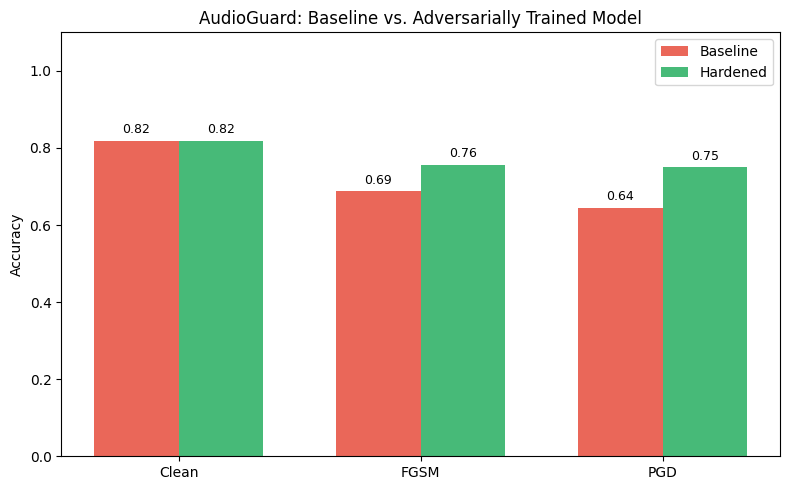

Saved: /content/drive/MyDrive/audioguard/figures/robustness_comparison_20260623_045547.png


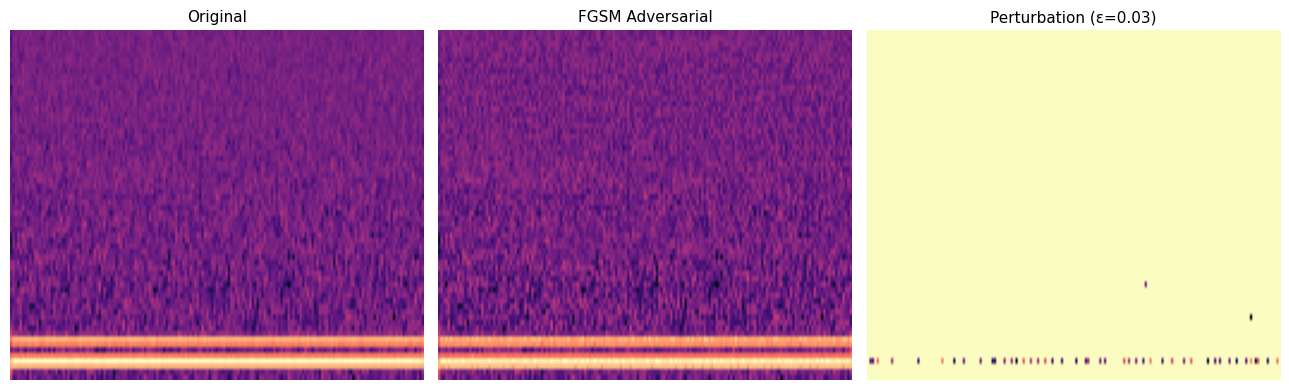

Saved: /content/drive/MyDrive/audioguard/figures/perturbation_visual_20260623_045547.png


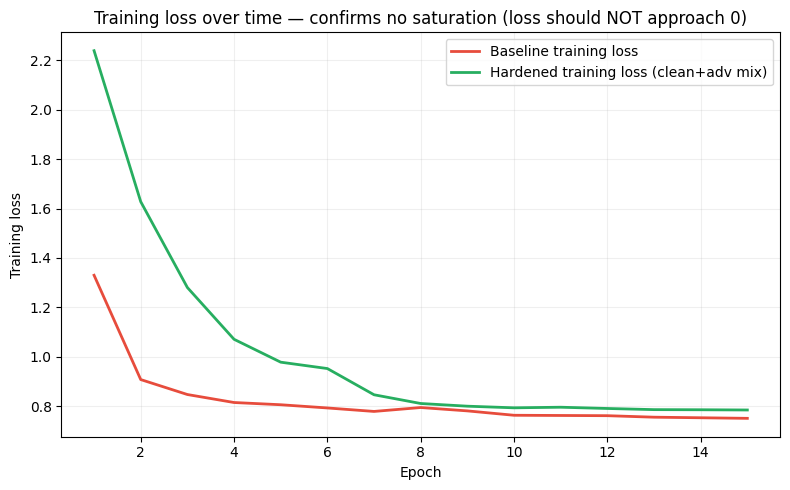

Saved: /content/drive/MyDrive/audioguard/figures/training_curves_20260623_045547.png


In [ ]:
# ── Plot 1: Robustness comparison bar chart ──────────────────────────────
conditions = ["Clean", "FGSM", "PGD"]
base_vals  = [clean_acc,      fgsm_acc_baseline, pgd_acc_baseline]
hard_vals  = [hardened_clean, fgsm_acc_hardened, pgd_acc_hardened]

x     = np.arange(len(conditions))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, base_vals, width, label="Baseline", color="#e74c3c", alpha=0.85)
ax.bar(x + width/2, hard_vals, width, label="Hardened", color="#27ae60", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(conditions)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.1)
ax.set_title("AudioGuard: Baseline vs. Adversarially Trained Model")
ax.legend()
for xi, (bv, hv) in enumerate(zip(base_vals, hard_vals)):
    ax.text(xi - width/2, bv + 0.02, f"{bv:.2f}", ha="center", fontsize=9)
    ax.text(xi + width/2, hv + 0.02, f"{hv:.2f}", ha="center", fontsize=9)
plt.tight_layout()
out = FIGURES_DIR / f"robustness_comparison_{RUN_ID}.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

# ── Plot 2: Adversarial perturbation visualization ──────────────────
sample_X = X_val[:1].to(DEVICE)
sample_y = y_val[:1]
adv_X    = fgsm_attack(model_baseline, sample_X, sample_y)
perturbation = (adv_X - sample_X).abs().cpu()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, data, title in zip(
    axes,
    [sample_X.cpu()[0, 0], adv_X.cpu()[0, 0], perturbation[0, 0]],
    ["Original", "FGSM Adversarial", f"Perturbation (ε={FGSM_EPS})"],
):
    ax.imshow(data.numpy(), aspect="auto", origin="lower", cmap="magma")
    ax.set_title(title, fontsize=11)
    ax.axis("off")
plt.tight_layout()
out2 = FIGURES_DIR / f"perturbation_visual_{RUN_ID}.png"
plt.savefig(out2, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", out2)

# ── Plot 3: Training curves — baseline vs hardened loss over epochs ─────
if 'history_baseline' in dir() and 'adv_history' in dir():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history_baseline['epoch'], history_baseline['train_loss'],
            label='Baseline training loss', color='#e74c3c', linewidth=2)
    adv_df = pd.DataFrame(adv_history)
    ax.plot(adv_df['epoch'], adv_df['loss'],
            label='Hardened training loss (clean+adv mix)', color='#27ae60', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training loss')
    ax.set_title('Training loss over time — confirms no saturation (loss should NOT approach 0)')
    ax.legend()
    ax.grid(alpha=0.2)
    plt.tight_layout()
    out3 = FIGURES_DIR / f"training_curves_{RUN_ID}.png"
    plt.savefig(out3, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out3)


In [ ]:
print(baseline_ckpt)
print(baseline_ckpt.exists())

/content/drive/MyDrive/audioguard/checkpoints/baseline.pt
True


## 11. Recovery checklist

In [ ]:
print("""
Recovery order after a runtime restart:

1. Runtime check
2. Install packages
3. Imports / config / Drive paths
4. Dataset (regenerated each run — no file needed)
5. Model definition
6. Training helpers
7. Train baseline           -> set TRAIN_BASELINE=False to load from Drive
7b. Sanity check (gradients) -> re-run this any time results look suspiciously perfect
8. Adversarial attacks (evaluates baseline) — this is Section 8, not Section 7
9. Train hardened           -> set TRAIN_HARDENED=False to load from Drive
   *** Section 9 (train hardened) MUST finish before Section 10 (compare) runs ***
   *** If you see NameError: model_hardened not defined, re-run Section 9 first ***
10. Compare results
11. Plots

Checkpoint files on Drive:
  audioguard/checkpoints/baseline.pt
  audioguard/checkpoints/hardened.pt
""")



Recovery order after a runtime restart:

1. Runtime check
2. Install packages
3. Imports / config / Drive paths
4. Dataset (regenerated each run — no file needed)
5. Model definition
6. Training helpers
7. Train baseline           -> set TRAIN_BASELINE=False to load from Drive
7b. Sanity check (gradients) -> re-run this any time results look suspiciously perfect
8. Adversarial attacks (evaluates baseline) — this is Section 8, not Section 7
9. Train hardened           -> set TRAIN_HARDENED=False to load from Drive
   *** Section 9 (train hardened) MUST finish before Section 10 (compare) runs ***
   *** If you see NameError: model_hardened not defined, re-run Section 9 first ***
10. Compare results
11. Plots

Checkpoint files on Drive:
  audioguard/checkpoints/baseline.pt
  audioguard/checkpoints/hardened.pt



In [ ]:
import os
from pathlib import Path

PROJECT_NAME = "audioguard"
# Standardize on Drive paths for both reading results AND saving figures
DRIVE_BASE = f"/content/drive/MyDrive/{PROJECT_NAME}"
RESULTS_DIR = f"{DRIVE_BASE}/results"
FIGURES_DIR = f"{DRIVE_BASE}/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Redirect plt.savefig so every visualization script saves to Drive automatically
import matplotlib.pyplot as plt
_original_savefig = plt.savefig
def savefig_to_drive(fname, *args, **kwargs):
    fname = fname.replace('figures/', f'{FIGURES_DIR}/')
    return _original_savefig(fname, *args, **kwargs)
plt.savefig = savefig_to_drive

# Find and load the most recent results file automatically
import json
result_files = sorted(Path(RESULTS_DIR).glob('results_*.json'))
if not result_files:
    raise FileNotFoundError(f"No results_*.json found in {RESULTS_DIR} — run the notebook's results-saving cell first")

latest = result_files[-1]
with open(latest) as f:
    results = json.load(f)
print(f"✓ Loaded: {latest.name}")
print(results)

✓ Loaded: results_20260623_045547.json
{'baseline': {'clean': 0.81875, 'fgsm': 0.6875, 'pgd': 0.64375}, 'hardened': {'clean': 0.81875, 'fgsm': 0.75625, 'pgd': 0.75}}


## 12. Visualizations

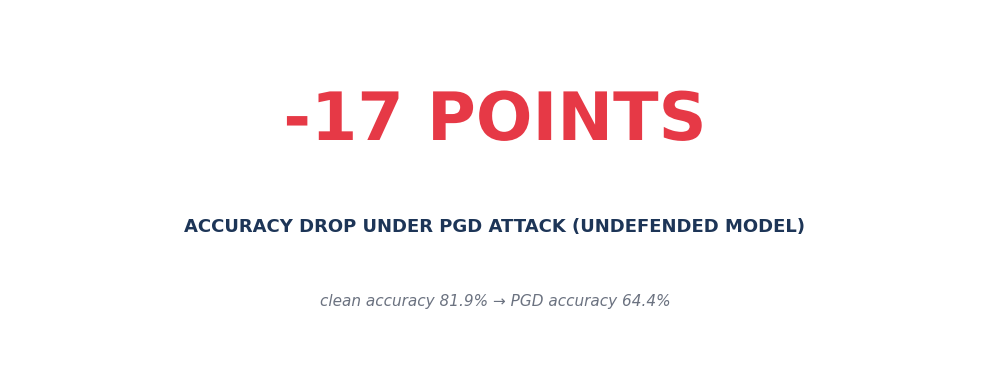

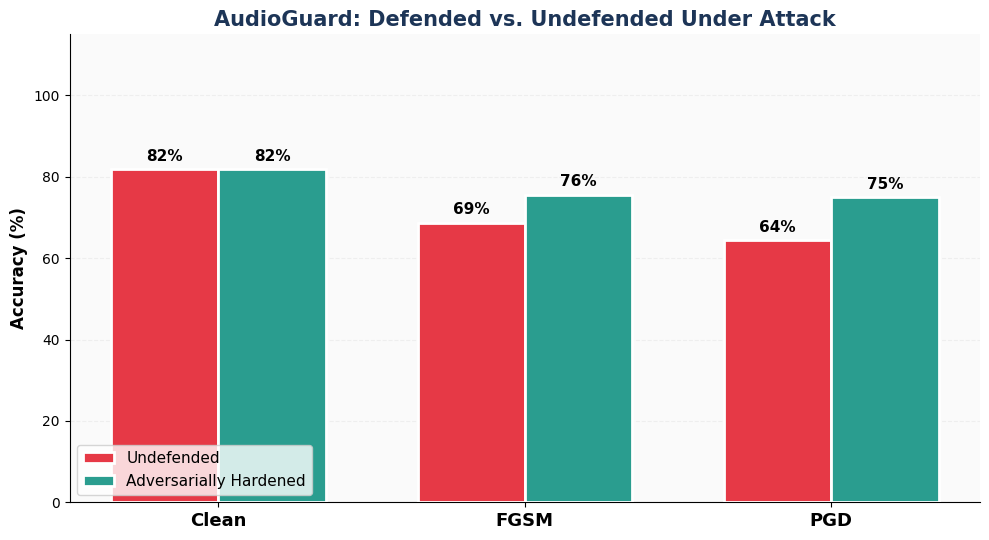

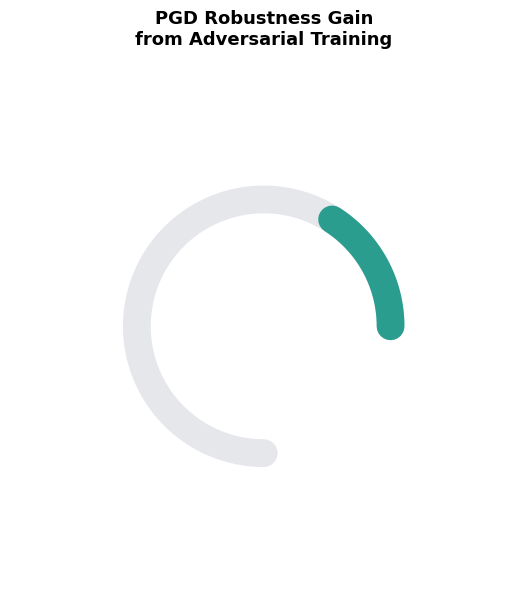

All AudioGuard portfolio visuals saved to figures/


In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as path_effects

ALARM_RED  = '#E63946'
SHIELD_GREEN = '#2A9D8F'
INK = '#1D3557'

# ── VISUAL 1: Shield stat card ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

clean = results['baseline']['clean'] * 100
fgsm_drop = (results['baseline']['clean'] - results['baseline']['fgsm']) * 100
pgd_drop  = (results['baseline']['clean'] - results['baseline']['pgd']) * 100

ax.text(5, 2.8, f'-{pgd_drop:.0f} POINTS', ha='center', va='center',
        fontsize=48, fontweight='bold', color=ALARM_RED,
        path_effects=[path_effects.withStroke(linewidth=4, foreground='white')])
ax.text(5, 1.6, 'ACCURACY DROP UNDER PGD ATTACK (UNDEFENDED MODEL)', ha='center',
        fontsize=13, fontweight='bold', color=INK)
ax.text(5, 0.8, f'clean accuracy {clean:.1f}% \u2192 PGD accuracy {results["baseline"]["pgd"]*100:.1f}%',
        ha='center', fontsize=11, color='#6B7280', style='italic')
ax.set_xlim(0, 10); ax.set_ylim(0, 4)
plt.tight_layout()
plt.savefig('figures/portfolio_stat_card.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


# ── VISUAL 2: Shield bars — baseline (vulnerable) vs hardened (defended) ─
conditions = ['Clean', 'FGSM', 'PGD']
base_vals  = [results['baseline'][k] * 100 for k in ['clean', 'fgsm', 'pgd']]
hard_vals  = [results['hardened'][k] * 100 for k in ['clean', 'fgsm', 'pgd']]

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(conditions)); width = 0.35

bars1 = ax.bar(x - width/2, base_vals, width, label='Undefended', color=ALARM_RED,
               edgecolor='white', linewidth=2, zorder=3)
bars2 = ax.bar(x + width/2, hard_vals, width, label='Adversarially Hardened', color=SHIELD_GREEN,
               edgecolor='white', linewidth=2, zorder=3)

for b, v in zip(bars1, base_vals):
    ax.text(b.get_x() + b.get_width()/2, v + 2, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=11)
for b, v in zip(bars2, hard_vals):
    ax.text(b.get_x() + b.get_width()/2, v + 2, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=11)

ax.set_xticks(x); ax.set_xticklabels(conditions, fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 115)
ax.set_title('AudioGuard: Defended vs. Undefended Under Attack', fontsize=15, fontweight='bold', color=INK)
ax.legend(fontsize=11, loc='lower left')
ax.set_facecolor('#FAFAFA')
ax.grid(axis='y', alpha=0.15, linestyle='--')
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('figures/portfolio_shield_bars.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


# ── VISUAL 3: Radial "armor" gauge — robustness gain ────────────────────
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
pgd_gain = (results['hardened']['pgd'] - results['baseline']['pgd']) * 100

theta = np.linspace(0, 1.5 * np.pi, 100)
ax.plot(theta, [1]*len(theta), color='#E5E7EB', linewidth=20, solid_capstyle='round')
gain_frac = min(pgd_gain / 50, 1.0)  # scale to a 0-50pt gain range
theta_fill = np.linspace(0, 1.5 * np.pi * gain_frac, 100)
ax.plot(theta_fill, [1]*len(theta_fill), color=SHIELD_GREEN, linewidth=20, solid_capstyle='round')

ax.text(0, 0, f'+{pgd_gain:.0f}pts', ha='center', va='center', fontsize=28,
        fontweight='bold', color=SHIELD_GREEN)
ax.set_title('PGD Robustness Gain\nfrom Adversarial Training', fontsize=13, fontweight='bold', pad=20)
ax.set_xticks([]); ax.set_yticks([]); ax.spines['polar'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/portfolio_armor_gauge.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print("All AudioGuard portfolio visuals saved to figures/")
